In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [ ]:
import zipfile

zip_path = "/content/human+activity+recognition+using+smartphones.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/UCI_HAR")

print("Done")

Done


In [ ]:
import os

print(os.listdir("/content"))

['.config', 'UCI_HAR', 'human+activity+recognition+using+smartphones.zip', 'sample_data']


In [ ]:
import zipfile

with zipfile.ZipFile(
    "/content/UCI_HAR/UCI HAR Dataset.zip",
    "r"
) as zip_ref:

    zip_ref.extractall("/content/UCI_HAR")

print("Done")

Done


In [ ]:
import os

print(os.listdir("/content/UCI_HAR"))

['UCI HAR Dataset.zip', 'UCI HAR Dataset', 'UCI HAR Dataset.names', '__MACOSX']


In [ ]:
import os

base_path = "/content/UCI_HAR/UCI HAR Dataset"

print(os.listdir(base_path))

['README.txt', 'activity_labels.txt', 'features_info.txt', 'train', '.DS_Store', 'features.txt', 'test']


In [ ]:
import os

signal_path = "/content/UCI_HAR/UCI HAR Dataset/train/Inertial Signals"

print(os.listdir(signal_path))

['body_gyro_z_train.txt', 'total_acc_z_train.txt', 'body_gyro_y_train.txt', 'body_acc_z_train.txt', 'body_gyro_x_train.txt', 'body_acc_x_train.txt', 'body_acc_y_train.txt', 'total_acc_x_train.txt', 'total_acc_y_train.txt']


In [ ]:
import numpy as np

base_path = "/content/UCI_HAR/UCI HAR Dataset"

signals = [
    "body_acc_x",
    "body_acc_y",
    "body_acc_z",
    "body_gyro_x",
    "body_gyro_y",
    "body_gyro_z",
    "total_acc_x",
    "total_acc_y",
    "total_acc_z"
]

def load_signals(split):

    signal_data = []

    for signal in signals:

        path = f"{base_path}/{split}/Inertial Signals/{signal}_{split}.txt"

        data = np.loadtxt(path)

        signal_data.append(data)

    signal_data = np.array(signal_data)

    signal_data = np.transpose(signal_data, (1, 2, 0))

    return signal_data


X_train = load_signals("train")
X_test = load_signals("test")

y_train = np.loadtxt(
    f"{base_path}/train/y_train.txt"
).astype(int) - 1

y_test = np.loadtxt(
    f"{base_path}/test/y_test.txt"
).astype(int) - 1

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (7352, 128, 9)
X_test : (2947, 128, 9)
y_train: (7352,)
y_test : (2947,)


In [ ]:
from tensorflow.keras.utils import to_categorical

y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

print("y_train_cat:", y_train_cat.shape)
print("y_test_cat :", y_test_cat.shape)

y_train_cat: (7352, 6)
y_test_cat : (2947, 6)


In [ ]:
from collections import Counter

print("Train")
print(Counter(y_train))

print("\nTest")
print(Counter(y_test))

Train
Counter({np.int64(5): 1407, np.int64(4): 1374, np.int64(3): 1286, np.int64(0): 1226, np.int64(1): 1073, np.int64(2): 986})

Test
Counter({np.int64(5): 537, np.int64(4): 532, np.int64(0): 496, np.int64(3): 491, np.int64(1): 471, np.int64(2): 420})


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

baseline_model = Sequential()

baseline_model.add(
    LSTM(
        128,
        return_sequences=True,
        input_shape=(128, 9)
    )
)

baseline_model.add(
    Dropout(0.3)
)

baseline_model.add(
    LSTM(64)
)

baseline_model.add(
    Dropout(0.3)
)

baseline_model.add(
    Dense(
        64,
        activation='relu'
    )
)

baseline_model.add(
    Dropout(0.2)
)

baseline_model.add(
    Dense(
        6,
        activation='softmax'
    )
)

baseline_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 128, 128)       │        70,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 124,614 (486.77 KB)

 Trainable params: 124,614 (486.77 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential()

model.add(LSTM(128, return_sequences=True, input_shape=(128, 9)))
model.add(Dropout(0.2))

model.add(LSTM(128, return_sequences=True))
model.add(Dropout(0.2))

model.add(LSTM(64))
model.add(Dropout(0.2))

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(6, activation='softmax'))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 128, 128)       │        70,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 128, 128)       │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 260,742 (1018.52 KB)

 Trainable params: 260,742 (1018.52 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train,
    y_train_cat,
    validation_split=0.15,
    epochs=20,
    batch_size=64,
    verbose=1
)

Epoch 1/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.5273 - loss: 1.0845 - val_accuracy: 0.5630 - val_loss: 1.1057
Epoch 2/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.7084 - loss: 0.6751 - val_accuracy: 0.6709 - val_loss: 0.8564
Epoch 3/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.8198 - loss: 0.4525 - val_accuracy: 0.7724 - val_loss: 0.7546
Epoch 4/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.8366 - loss: 0.4050 - val_accuracy: 0.8268 - val_loss: 0.5464
Epoch 5/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9237 - loss: 0.2375 - val_accuracy: 0.8631 - val_loss: 0.5171
Epoch 6/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9365 - loss: 0.1870 - val_accuracy: 0.8413 - val_loss: 0.6679
Epoch 7/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9339 - loss: 0.1928 - val_accuracy: 0.8395 - val_loss: 0.4218
Epoch 8/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.9568 - loss: 0.1205 - val_accuracy: 0.8758 - 

In [ ]:
test_loss, test_acc = model.evaluate(
    X_test,
    y_test_cat,
    verbose=0
)

print("Test Accuracy:", test_acc)

Test Accuracy: 0.9053274393081665


ONE LAYER TEST-2

In [ ]:
model_128 = Sequential()

model_128.add(
    LSTM(
        128,
        input_shape=(128, 9)
    )
)

model_128.add(Dropout(0.2))

model_128.add(Dense(128, activation='relu'))

model_128.add(Dropout(0.2))

model_128.add(Dense(6, activation='softmax'))

model_128.compile(
    optimizer=Adam(0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_128 = model_128.fit(
    X_train,
    y_train_cat,
    validation_split=0.15,
    epochs=40,
    batch_size=8,
    verbose=1
)

Epoch 1/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.6068 - loss: 0.9278 - val_accuracy: 0.6791 - val_loss: 0.9399
Epoch 2/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.7369 - loss: 0.6001 - val_accuracy: 0.7117 - val_loss: 0.7634
Epoch 3/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.7734 - loss: 0.5050 - val_accuracy: 0.6963 - val_loss: 1.0596
Epoch 4/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.8092 - loss: 0.4587 - val_accuracy: 0.8005 - val_loss: 0.6993
Epoch 5/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.8813 - loss: 0.3142 - val_accuracy: 0.7851 - val_loss: 0.7997
Epoch 6/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9216 - loss: 0.2282 - val_accuracy: 0.8486 - val_loss: 0.5292
Epoch 7/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9232 - loss: 0.2154 - val_accuracy: 0.8540 - val_loss: 0.5645
Epoch 8/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9344 - loss: 0.1885 - val_

In [ ]:
test_loss, test_acc = model_128.evaluate(
    X_test,
    y_test_cat,
    verbose=0
)

print("Test Accuracy:", test_acc)

Test Accuracy: 0.913810670375824


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_pred = np.argmax(
    model_128.predict(X_test),
    axis=1
)

cm = confusion_matrix(y_test, y_pred)

print(cm)

print(classification_report(
    y_test,
    y_pred,
    digits=4
))

93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
[[469  17  10   0   0   0]
 [  7 461   3   0   0   0]
 [  5   2 413   0   0   0]
 [  0   2   0 426  59   4]
 [  0   0   0 125 407   0]
 [  0  20   0   0   0 517]]
              precision    recall  f1-score   support

           0     0.9751    0.9456    0.9601       496
           1     0.9183    0.9788    0.9476       471
           2     0.9695    0.9833    0.9764       420
           3     0.7731    0.8676    0.8177       491
           4     0.8734    0.7650    0.8156       532
           5     0.9923    0.9628    0.9773       537

    accuracy                         0.9138      2947
   macro avg     0.9170    0.9172    0.9158      2947
weighted avg     0.9163    0.9138    0.9137      2947



93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


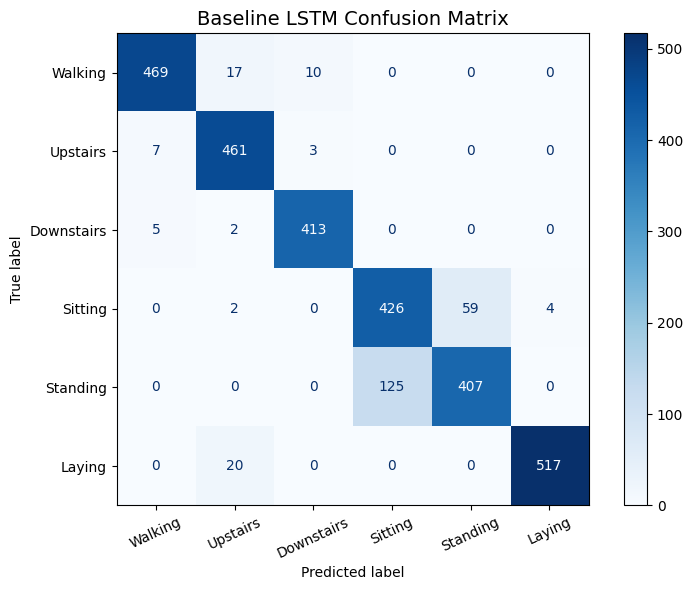

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Predictions
y_pred = np.argmax(model_128.predict(X_test), axis=1)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Class Names
classes = [
    "Walking",
    "Upstairs",
    "Downstairs",
    "Sitting",
    "Standing",
    "Laying"
]

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

disp.plot(
    cmap=plt.cm.Blues,
    values_format='d',
    ax=ax,
    colorbar=True
)

plt.title("Baseline LSTM Confusion Matrix", fontsize=14)
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

REWARD SHAPING

In [ ]:
import numpy as np

reward_matrix = np.zeros((6, 6), dtype=np.float32)

# Penalize dominant confusion
reward_matrix[3, 4] = 0.05   # Sitting -> Standing
reward_matrix[4, 3] = 0.05   # Standing -> Sitting

print(reward_matrix)

[[0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.05 0.  ]
 [0.   0.   0.   0.05 0.   0.  ]
 [0.   0.   0.   0.   0.   0.  ]]


In [ ]:
import tensorflow as tf

reward_matrix_tf = tf.constant(
    reward_matrix,
    dtype=tf.float32
)

def reward_shaped_loss(y_true, y_pred):

    ce_loss = tf.keras.losses.categorical_crossentropy(
        y_true,
        y_pred
    )

    true_class = tf.argmax(
        y_true,
        axis=1
    )

    pred_class = tf.argmax(
        y_pred,
        axis=1
    )

    penalties = tf.gather_nd(
        reward_matrix_tf,
        tf.stack(
            [true_class, pred_class],
            axis=1
        )
    )

    return ce_loss + penalties

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

reward_model = Sequential()

reward_model.add(
    LSTM(
        128,
        input_shape=(128, 9)
    )
)

reward_model.add(
    Dropout(0.2)
)

reward_model.add(
    Dense(
        128,
        activation='relu'
    )
)

reward_model.add(
    Dropout(0.2)
)

reward_model.add(
    Dense(
        6,
        activation='softmax'
    )
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
from tensorflow.keras.optimizers import Adam

reward_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=reward_shaped_loss,
    metrics=['accuracy']
)

In [ ]:
history_reward = reward_model.fit(
    X_train,
    y_train_cat,
    validation_split=0.15,
    epochs=40,
    batch_size=8,
    verbose=1
)

Epoch 1/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.5785 - loss: 0.9956 - val_accuracy: 0.4134 - val_loss: 1.3774
Epoch 2/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.6191 - loss: 0.8445 - val_accuracy: 0.5793 - val_loss: 1.0346
Epoch 3/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.7044 - loss: 0.6799 - val_accuracy: 0.6464 - val_loss: 1.0056
Epoch 4/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.7905 - loss: 0.5490 - val_accuracy: 0.7688 - val_loss: 0.8711
Epoch 5/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.8632 - loss: 0.3771 - val_accuracy: 0.8241 - val_loss: 0.8603
Epoch 6/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9097 - loss: 0.2452 - val_accuracy: 0.8296 - val_loss: 0.7546
Epoch 7/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9243 - loss: 0.2126 - val_accuracy: 0.8694 - val_loss: 0.7147
Epoch 8/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9464 - loss: 0.1455 - val_ac

In [ ]:
test_loss, test_acc = reward_model.evaluate(
    X_test,
    y_test_cat,
    verbose=0
)

print("Reward-Shaped Test Accuracy:", test_acc)

Reward-Shaped Test Accuracy: 0.9185612201690674


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_pred_reward = np.argmax(
    reward_model.predict(X_test),
    axis=1
)

cm_reward = confusion_matrix(
    y_test,
    y_pred_reward
)

print(cm_reward)

print(
    classification_report(
        y_test,
        y_pred_reward,
        digits=4
    )
)

93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
[[467   2  27   0   0   0]
 [  5 446  20   0   0   0]
 [  0   6 414   0   0   0]
 [  0  18   0 409  58   6]
 [  0   0   0  89 443   0]
 [  0   9   0   0   0 528]]
              precision    recall  f1-score   support

           0     0.9894    0.9415    0.9649       496
           1     0.9272    0.9469    0.9370       471
           2     0.8980    0.9857    0.9398       420
           3     0.8213    0.8330    0.8271       491
           4     0.8842    0.8327    0.8577       532
           5     0.9888    0.9832    0.9860       537

    accuracy                         0.9186      2947
   macro avg     0.9182    0.9205    0.9187      2947
weighted avg     0.9193    0.9186    0.9184      2947



93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


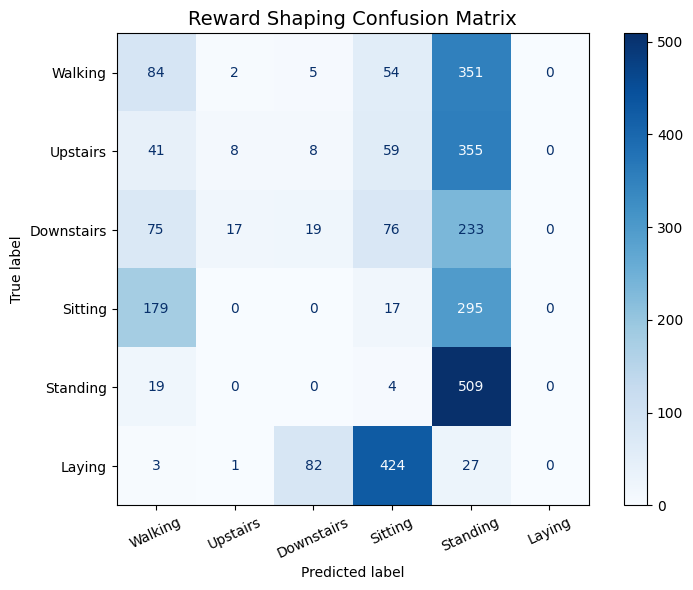

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Predictions
y_pred_reward = np.argmax(
    reward_model.predict(X_test),
    axis=1
)

# Confusion Matrix
cm_reward = confusion_matrix(
    y_test,
    y_pred_reward
)

classes = [
    "Walking",
    "Upstairs",
    "Downstairs",
    "Sitting",
    "Standing",
    "Laying"
]

fig, ax = plt.subplots(figsize=(8,6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_reward,
    display_labels=classes
)

disp.plot(
    cmap=plt.cm.Blues,
    values_format='d',
    ax=ax,
    colorbar=True
)

plt.title("Reward Shaping Confusion Matrix", fontsize=14)
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

REWARD SHAPING 2

In [ ]:
import tensorflow as tf

def reward_shaped_loss(y_true, y_pred):

    ce_loss = tf.keras.losses.categorical_crossentropy(
        y_true,
        y_pred
    )

    reward = tf.reduce_sum(
        y_true * y_pred,
        axis=1
    )

    return ce_loss - 0.1 * reward

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

reward_model = Sequential()

reward_model.add(
    LSTM(
        128,
        input_shape=(128, 9)
    )
)

reward_model.add(
    Dropout(0.2)
)

reward_model.add(
    Dense(
        128,
        activation='relu'
    )
)

reward_model.add(
    Dropout(0.2)
)

reward_model.add(
    Dense(
        6,
        activation='softmax'
    )
)

reward_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_7 (LSTM)                   │ (None, 128)            │        70,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 87,942 (343.52 KB)

 Trainable params: 87,942 (343.52 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.optimizers import Adam

reward_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=reward_shaped_loss,
    metrics=['accuracy']
)

In [ ]:
history_reward = reward_model.fit(
    X_train,
    y_train_cat,
    validation_split=0.15,
    epochs=40,
    batch_size=8,
    verbose=1
)

Epoch 1/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 21ms/step - accuracy: 0.5966 - loss: 0.8695 - val_accuracy: 0.5993 - val_loss: 0.9400
Epoch 2/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.7886 - loss: 0.4407 - val_accuracy: 0.8341 - val_loss: 0.6669
Epoch 3/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.8694 - loss: 0.2843 - val_accuracy: 0.8667 - val_loss: 0.7751
Epoch 4/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9200 - loss: 0.1504 - val_accuracy: 0.8640 - val_loss: 0.5084
Epoch 5/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9104 - loss: 0.1765 - val_accuracy: 0.8658 - val_loss: 0.6231
Epoch 6/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9179 - loss: 0.1417 - val_accuracy: 0.8368 - val_loss: 0.8485
Epoch 7/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9392 - loss: 0.0717 - val_accuracy: 0.8595 - val_loss: 0.7266
Epoch 8/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9507 - loss: 0.0373 - val_ac

In [ ]:
print("Best Validation Accuracy:",
      max(history_reward.history['val_accuracy']))

Best Validation Accuracy: 0.9011785984039307


In [ ]:
test_loss, test_acc = reward_model.evaluate(
    X_test,
    y_test_cat,
    verbose=0
)

print("Reward-Shaped Test Accuracy:", test_acc)

Reward-Shaped Test Accuracy: 0.9046487808227539


93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


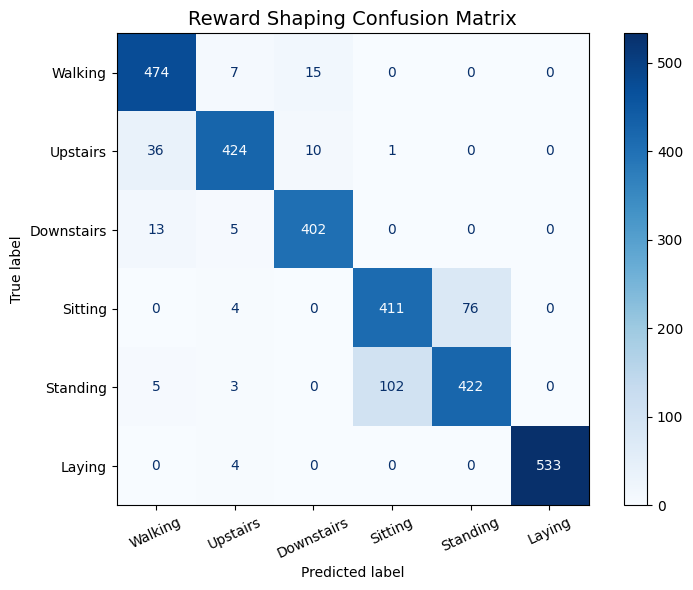

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Predictions
y_pred_reward = np.argmax(
    reward_model.predict(X_test),
    axis=1
)

# Confusion Matrix
cm_reward = confusion_matrix(
    y_test,
    y_pred_reward
)

classes = [
    "Walking",
    "Upstairs",
    "Downstairs",
    "Sitting",
    "Standing",
    "Laying"
]

fig, ax = plt.subplots(figsize=(8,6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_reward,
    display_labels=classes
)

disp.plot(
    cmap=plt.cm.Blues,
    values_format='d',
    ax=ax,
    colorbar=True
)

plt.title("Reward Shaping Confusion Matrix", fontsize=14)
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

REWARD SHAPING 3

In [ ]:
import numpy as np
import tensorflow as tf

f1_scores = np.array([
    0.9512,  # Walking
    0.9409,  # Upstairs
    0.9810,  # Downstairs
    0.8123,  # Sitting
    0.8319,  # Standing
    0.9802   # Laying
])

reward_weights = 1.0 / f1_scores

reward_weights = reward_weights / reward_weights.mean()

print("Reward Weights:")
print(reward_weights)

reward_weights_tf = tf.constant(
    reward_weights,
    dtype=tf.float32
)

Reward Weights:
[0.95764242 0.9681257  0.92855196 1.12139539 1.09497472 0.92930981]


In [ ]:
import tensorflow as tf

def f1_reward_loss(y_true, y_pred):

    ce_loss = tf.keras.losses.categorical_crossentropy(
        y_true,
        y_pred
    )

    true_class = tf.argmax(
        y_true,
        axis=1
    )

    class_reward = tf.gather(
        reward_weights_tf,
        true_class
    )

    correct_prob = tf.reduce_sum(
        y_true * y_pred,
        axis=1
    )

    reward = class_reward * correct_prob

    return ce_loss - 0.05 * reward

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

reward_model_f1 = Sequential()

reward_model_f1.add(
    LSTM(
        128,
        input_shape=(128, 9)
    )
)

reward_model_f1.add(
    Dropout(0.2)
)

reward_model_f1.add(
    Dense(
        128,
        activation='relu'
    )
)

reward_model_f1.add(
    Dropout(0.2)
)

reward_model_f1.add(
    Dense(
        6,
        activation='softmax'
    )
)

reward_model_f1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 128)            │        70,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 87,942 (343.52 KB)

 Trainable params: 87,942 (343.52 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.optimizers import Adam

reward_model_f1.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=f1_reward_loss,
    metrics=['accuracy']
)

In [ ]:
history_f1 = reward_model_f1.fit(
    X_train,
    y_train_cat,
    validation_split=0.15,
    epochs=40,
    batch_size=8,
    verbose=1
)

Epoch 1/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.4591 - loss: 1.2714 - val_accuracy: 0.4352 - val_loss: 1.4369
Epoch 2/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.5779 - loss: 0.9785 - val_accuracy: 0.5666 - val_loss: 0.9887
Epoch 3/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.7110 - loss: 0.6426 - val_accuracy: 0.6972 - val_loss: 0.9240
Epoch 4/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.8060 - loss: 0.4641 - val_accuracy: 0.8051 - val_loss: 0.7544
Epoch 5/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.8843 - loss: 0.2627 - val_accuracy: 0.8676 - val_loss: 0.5777
Epoch 6/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9133 - loss: 0.1973 - val_accuracy: 0.8558 - val_loss: 0.5282
Epoch 7/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9440 - loss: 0.1081 - val_accuracy: 0.8785 - val_loss: 0.5695
Epoch 8/40
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9506 - loss: 0.0870 - val_acc

In [ ]:
print(max(history_f1.history['val_accuracy']))

0.9129646420478821
